

# Moving Averages and Evaluating a Model
### OPIM 5641 — Business Decision Modeling · Module1

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/Module1/Moving Averages and Evaluating a Model.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Python Data Basics, Moving Averages and Evaluating a Model
---------------------------------
**Dr. Dave Wanik - University of Connecticut**

The purpose of this notebook is to get students comfortable with basic data analysis for supply chain and finance problems. 

By the end of this lesson, students will be able to:
* Create and slice Python data structures (lists vs. dictionaries, numpy arrays vs. pandas dataframes)
* Import common Python libraries for data wrangling and plotting
* Describe, fit and evalaute a the moving average model model (by defining your own function vs. using built-in functions from numpy and pandas)
* Write math formulas in $\LaTeX$

This content comes from the first two chapters of this book:
* "Data Science for Supply Chain Forecasting" 2nd Edition, by Nicolas Vandeput

**What I like about this notebook:**
* Students get exposure to a simple, intuitive and effective model. 
* Students can recreate all of this in Excel, but will see that they can be faster and better in Python!
* Some students may have heard of error metrics (or forecast KPIs as Vandeput calls them) but have not delved into the details of the formulas - we present the math formula, code examples and useful built-in functions from common libraries (like pandas).

**Key Python skills:**
Students should be able to fill in the notebook in key areas (from memory!) related to:
* Slicing lists, dictionaries and dataframes
* Adding a new column to a dataframe
* Renaming the columns in a dataframe


# List

In [206]:
ts = [1,2,3,4,5,6]

In [207]:
ts2 = [10,20,30,40,50,60]

In [208]:
# just returns a longer list...
# it appended one list to another
# useful, but this is not what we wanted!
ts+ts2

[1, 2, 3, 4, 5, 6, 10, 20, 30, 40, 50, 60]

# `numpy`

In [209]:
import numpy as np
ts = np.array([1,2,3,4,5,6])
ts

array([1, 2, 3, 4, 5, 6])

In [210]:
ts2 = np.array([10,20,30,40,50,60])
ts2

array([10, 20, 30, 40, 50, 60])

In [211]:
# this is what we wanted!
ts+ts2

array([11, 22, 33, 44, 55, 66])

Note that the output of `ts`, `ts2` and `ts+ts2` are all numpy arrays - not lists!

However, numpy works well with lists - for example...

In [212]:
myList = [1,2,3]
np.mean(myList)

2.0

# Slicing
To select a particular value in a list (or a numpy array), you simply have to indicate the location (known as the 'index') between the `[ ]` square brackets.

In [213]:
# slicing a list of string data
myList = ['cat', 'dog', 'mouse']
myList[1]

'dog'

In [214]:
# slicing a list of numeric data
myList = [1,2,3]
myList[0] # remember - Python counts from zero!

1

If you want to select multiple elements from a list, you can use a range with the format `start:end`.

Pay attention that the end result will include the `start` element but exclude the `end` element.

In [215]:
myList = ['cat', 'dog', 'mouse', 'elephant']
myList[1:]

['dog', 'mouse', 'elephant']

In [216]:
myList = ['cat', 'dog', 'mouse', 'elephant']
myList[1:3]

['dog', 'mouse']

If you give a negative value at the end, it will start counting backward from the last element of your list.

In [217]:
myList = ['cat', 'dog', 'mouse', 'elephant']
myList[:-1]

['cat', 'dog', 'mouse']

In [218]:
myList = ['cat', 'dog', 'mouse', 'elephant']
myList[:-2]

['cat', 'dog']

# `pandas`

In [219]:
[ts,ts2]

[array([1, 2, 3, 4, 5, 6]), array([10, 20, 30, 40, 50, 60])]

In [220]:
import pandas as pd
pd.DataFrame([ts,ts2])

,0,1,2,3,4,5
0,1,2,3,4,5,6
1,10,20,30,40,50,60


## Slicing Dataframes

In [221]:
df = pd.DataFrame([ts,ts2])
# look at first few rows
df.head(n=5)

,0,1,2,3,4,5
0,1,2,3,4,5,6
1,10,20,30,40,50,60


To change the column names, we make a list then specify this as an attribute of the pandas dataframe.

In [222]:
# print out the columns
df.columns

RangeIndex(start=0, stop=6, step=1)

In [223]:
# change column names
df.columns = ['Day1', 'Day2', 'Day3', 'Day4', 'Day5', 'Day6']
df # check your work! 

,Day1,Day2,Day3,Day4,Day5,Day6
0,1,2,3,4,5,6
1,10,20,30,40,50,60


### Selecting a single column and all rows

Now let's try a few ways of selecting the first column, `Day1`.

In [224]:
# single quotes
df['Day1']

0     1
1    10
Name: Day1, dtype: int64

In [225]:
# double quotes (don't mix and match single and double quotes! pick one and use it for life)
df["Day1"]

0     1
1    10
Name: Day1, dtype: int64

In [226]:
# you can use a period instead of square brackets
# but I personally don't like that column names don't light-up red!
df.Day1

0     1
1    10
Name: Day1, dtype: int64

In [227]:
myIndexValue = 0
# this locator (loc) selects the first row and a specific column by name
df.loc[myIndexValue,'Day1']

1

In [228]:
# iloc stands for 'integer locator' - specify the rows/columns you want
# by integer location!
df.iloc[0,0] # same as previous example!

1

### Selecting a more than one column and all rows

Let's try to select the first and third column. 

Remember - Python counts from zero!

In [229]:
# single quotes
df[['Day1','Day3']]

,Day1,Day3
0,1,3
1,10,30


In [230]:
# double quotes (don't mix and match single and double quotes! pick one and use it for life)
# otherwise it looks sloppiy
df[["Day1", "Day3"]]

,Day1,Day3
0,1,3
1,10,30


In [231]:
myIndexValue = 0
# this locator (loc) selects the first row and a specific column by name
x = df.loc[myIndexValue,['Day1', 'Day3']]
x 

Day1    1
Day3    3
Name: 0, dtype: int64

In [232]:
# but be careful... you went from a dataframe to a series!
type(x)

pandas.core.series.Series

In [233]:
# iloc stands for 'integer locator' - specify the rows/columns you want
# by integer location!
x = df.iloc[0,[0,2]] # same answer as previous example!
x 

Day1    1
Day3    3
Name: 0, dtype: int64

In [234]:
# again, be careful... you went from a dataframe to a series!
type(x)

pandas.core.series.Series

## Optional: transpose (`.T`)

Want it to look like an Excel spreadsheet? Take the transpose with `.T`

Transpose means the first row becomes the first column.

In [235]:
[ts,ts2]

[array([1, 2, 3, 4, 5, 6]), array([10, 20, 30, 40, 50, 60])]

In [236]:
pd.DataFrame([ts,ts2])

,0,1,2,3,4,5
0,1,2,3,4,5,6
1,10,20,30,40,50,60


In [237]:
df = pd.DataFrame([ts,ts2]).T
df

,0,1
0,1,10
1,2,20
2,3,30
3,4,40
4,5,50
5,6,60


In [238]:
df.rename(columns={0:'iPhones',
                   1:'iPads'})

,iPhones,iPads
0,1,10
1,2,20
2,3,30
3,4,40
4,5,50
5,6,60


# Dictionaries


In [239]:
d = {'Small product':ts, 'Big product':ts2}
d

{'Small product': array([1, 2, 3, 4, 5, 6]),
 'Big product': array([10, 20, 30, 40, 50, 60])}

Here the `key` value `'Small product'` and will give you the value `ts`. The `key` value `'Big product'` will give you `ts2`. 

In [240]:
# selecting the value from a dictionary based on a key
d['Small product']

array([1, 2, 3, 4, 5, 6])

In [241]:
# we can perform mathematical operations on the values!
d['Small product'] + d['Big product']

array([11, 22, 33, 44, 55, 66])

What's a nice perk about the dictionary? You don't have to worry about manipulating data as a function of position - you can query it directly based on a key.

Of course, we can also create a `pandas Dataframe` from this dictionary.

In [242]:
df = pd.DataFrame.from_dict(d)
df

,Small product,Big product
0,1,10
1,2,20
2,3,30
3,4,40
4,5,50
5,6,60


Now **THIS** is really starting to look like an Excel spreadsheet which can be easily manipulated.

Each column has its own column and each row is another period.

# Moving Average Function


## Writing your own function

In [243]:
def moving_average(d, extra_periods=1, n=3):
  # transform the input into a numpy array
  d = np.array(d)
  # historical period length
  cols = len(d)
  # append np.nan into the demand array to cover future periods
  d = np.append(d,[np.nan]*extra_periods)
  # define the forecast array
  f = np.full(cols + extra_periods, np.nan)

  # create the t+1 forecasts until end of the historical period
  for t in range(n, cols+1):
    f[t] = np.mean(d[t-n:t])
  
  # forecast for all extra periods
  f[cols+1:] = f[t]

  # return a dataframe with the demand, forecast and error
  df = pd.DataFrame.from_dict({'Demand':   d,
                               'Forecast': f,
                               "Error":    d-f})
  return df

Can you say what each part of the code does? If not, break it out line by line and examine it!

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

d = [28,19,18,13,19,16,19,18,17,13,16,16,11,18,15,13,15,13,11,13,10,12]
df = moving_average(d)
df

,Demand,Forecast,Error
0,28.0,NaN,NaN
1,19.0,NaN,NaN
2,18.0,NaN,NaN
3,13.0,21.666667,-8.666667
4,19.0,16.666667,2.333333
5,16.0,16.666667,-0.666667
6,19.0,16.000000,3.000000
7,18.0,18.000000,0.000000
8,17.0,17.666667,-0.666667
9,13.0,18.000000,-5.000000


## Visualizing the results with pandas

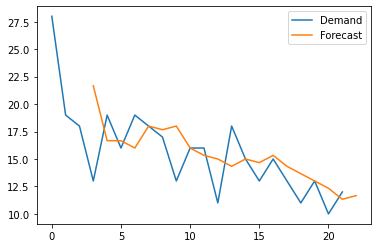

In [245]:
df[['Demand','Forecast']].plot()
plt.show()

## Customizing the plot
Let's add some parameters to make a nicer plot.

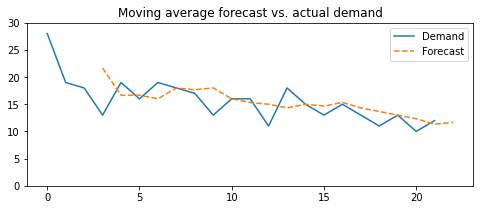

In [246]:
df[['Demand','Forecast']].plot(
    figsize=(8,3),
    title='Moving average forecast vs. actual demand',
    ylim=(0,30),
    style=['-','--']
)
plt.show()

##### **On your own:** use the moving average function from pandas!
Google 'moving average pandas' and see if you can recreate the results using a built-in function. See how easy it is?!

In [250]:
tmp = d
tmp = pd.DataFrame(d)
tmp.columns = ['Demand']
tmp['MovingAverageModel'] = tmp['Demand'].rolling(3).mean()
tmp

,Demand,MovingAverageModel
0,28,NaN
1,19,NaN
2,18,21.666667
3,13,16.666667
4,19,16.666667
5,16,16.000000
6,19,18.000000
7,18,17.666667
8,17,18.000000
9,13,16.000000


# Evaluate the model
Now that you have fit a model, it's time to evaluate the accuracy. There is no 'one size fits all' indicator or error metric that is appropriate for every model, the correct choice of metric(s) can vary based on the use case. 

For example, sometimes we want to emphasize how the model does with outliers vs. more common observations. Which metric would you use in this case?

When you are in a meeting, you should ALWAYS have the formula presented in your slides/documentation so that everyone understands how you evaluated your model.

Note that these error metrics are to be used for numeric target variables (regression problems).

## Error
$e_t = f_t - d_t$

where:
* $e_t$ is the error for time step $t$
* $f_t$ is the forecast for time step $t$
* $d_t$ is the actual demand for time step $t$

## Bias
The bias is defined as the average error per observation. In other words - does your model systematically overestimate or underestimate?

$b = \frac{1}{n} \displaystyle\sum_{t=1}^{∞} e_t$

where $n$ is the number of total time periods where you have both a forecast and actual (demand).

However, this method suffers from positive numbers and negative numbers canceling it out - you can have huge positive and negative errors, but when you sum them, they become zero! Even though bias is a solid metric to tell if the model tends to over or underestimate, we need more metrics to tell the full story.

The units of bias are on the same scale as the demand (actual).

## Mean Absolute Error
The absolute error is simply the absolute value of the error term. We can calculate the average absolute error per observation to say 'regardless of the sign, how far off was the model?'

$\text{MAE} = \frac{1}{n} \sum |e_t|$

The units of MAE are on the same scale as the demand (actual).

## Mean Absolute Percentage Error
For each observation, how off were you from the actual value (in terms of percentage)?

$\text{MAPE} = \frac{1}{n} \sum \frac{|e_t|}{d_t}$

The units of MAPE are a percentage.

The downside of MAPE is that MAPE divides each error per observation by the demand per observation. And so high errors during low demand periods will really skew the MAPE. As a result, in practice, optimizing a model to 'MAPE' may result in a model that underestimates. 

## Root Mean Square Error (RMSE)
It is defined as the square root of the average squared error.

$\text{RMSE} = \sqrt{ \frac{1}{n} \sum e_t^2}$

Many supply chain and data science models are optimized based on minimizing the Mean Square Error (MSE) which is directly related to RMSE.

$\text{MSE} = \frac{1}{n} \sum{e_t^2}$

The units of RMSE are the same as the demand (actual) variable. The units of MSE are units SQUARED.

# Evaluating the moving average model
Using the model evaluation metrics from the `sklearn` model makes it easy to evaluate the errors!

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

d = [28,19,18,13,19,16,19,18,17,13,16,16,11,18,15,13,15,13,11,13,10,12]
df = moving_average(d)
df

,Demand,Forecast,Error
0,28.0,NaN,NaN
1,19.0,NaN,NaN
2,18.0,NaN,NaN
3,13.0,21.666667,-8.666667
4,19.0,16.666667,2.333333
5,16.0,16.666667,-0.666667
6,19.0,16.000000,3.000000
7,18.0,18.000000,0.000000
8,17.0,17.666667,-0.666667
9,13.0,18.000000,-5.000000


Check the documentation to review the arguments to the functions:
* https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
* https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html\

To get RMSE, you need to add a keyword argument

```
squaredbool, default=True
If True returns MSE value, if False returns RMSE value.
```

In [253]:
# import useful functions to help us evaluate the model
# every sklearn library uses the convention `metric(actual, predicted)`
# you should use this convention, too!
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# uncomment this to get the error
# print('MAE:', mean_absolute_error(y_true=df['Demand'], y_pred=df['Forecast']))

ValueError: ignored

**Oops!** You have some NaN values in your forecast. You can drop rows and re-run.

In [255]:
df.dropna(inplace=True)
print('MAE:', mean_absolute_error(y_true=df['Demand'], y_pred=df['Forecast']))
print('MSE:', mean_squared_error(y_true=df['Demand'], y_pred=df['Forecast'], squared=True))
print('RMSE:', mean_squared_error(y_true=df['Demand'], y_pred=df['Forecast'], squared=False))

MAE: 1.9824561403508774
MSE: 8.578947368421055
RMSE: 2.9289840164161114


Of course MSE will always be bigger than RMSE!

# Theory
Let's show that RMSE inflates the error when there are outliers - that RMSE is very sensitive to outliers!

### An example of 'error weighting'
Compared to MAE, RMSE does not treat each error the same. It gives more importance to the biggest errors. That means ONE BIG ERROR is enough to get a very bad RMSE.

In [256]:
period = np.arange(1,13,1) # from 1 to 12 periods (notice endpoint is not included!)
period

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [257]:
demand = [10,12,14,8,9,5,8,10,12,11,10,15]
demand

[10, 12, 14, 8, 9, 5, 8, 10, 12, 11, 10, 15]

Why are we using a transpose? To get the data in long form.

In [258]:
df = pd.DataFrame([period,demand]).T
df.columns = ['period', 'demand']
df['period'] = df['period'].astype(int)
df

,period,demand
0,1,10
1,2,12
2,3,14
3,4,8
4,5,9
5,6,5
6,7,8
7,8,10
8,9,12
9,10,11


Now let's imagine we have two forecasts. We add them to the dataframe.

In [259]:
# note that the only difference between these two forecasts is the LAST observation
df['forecast1'] = [12,14,15,10,7,4,5,8,12,14,13,8]
df['forecast2'] = [12,14,15,10,7,4,5,8,12,14,13,9]

In [260]:
# check your work
df

,period,demand,forecast1,forecast2
0,1,10,12,12
1,2,12,14,14
2,3,14,15,15
3,4,8,10,10
4,5,9,7,7
5,6,5,4,4
6,7,8,5,5
7,8,10,8,8
8,9,12,12,12
9,10,11,14,14


As you can see, the only difference is the last forecast period.

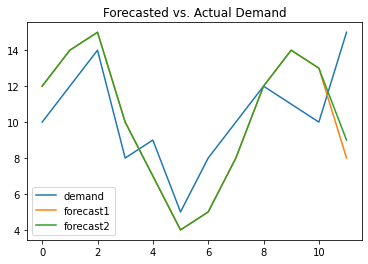

In [261]:
# look right...
df[['demand','forecast1','forecast2']].plot()
plt.title('Forecasted vs. Actual Demand') # it's always nice to add a title
plt.show()

Now let's calculate the errors and calculate two KPIs.

### Writing your own error metric functions
You can write it like an Excel function and keep track of mathematical order of operations, or you can be more advanced! I recommend starting small first and using the beginner version of the code.

In [262]:
# beginner version of defining your own function
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

In [263]:
# beginner version
def mae(y_true, y_pred):
  return np.mean(np.abs(y_pred - y_true))

In [181]:
# # advanced version - see how mean is at the end?
# def rmse(y_true, y_pred):
#     return np.sqrt(((y_pred - y_true) ** 2).mean())

In [182]:
# # advanced version
# def mae(y_true, y_pred):
#   return np.abs(y_pred - y_true).mean()

In [264]:
# for forecast 1
print('RMSE:', rmse(y_true=df['demand'], y_pred=df['forecast1']))
print('MAE:', mae(y_true=df['demand'], y_pred=df['forecast1']))

RMSE: 2.857738033247041
MAE: 2.3333333333333335


In [265]:
# for forecast 2
print('RMSE:', rmse(y_true=df['demand'], y_pred=df['forecast2']))
print('MAE:', mae(y_true=df['demand'], y_pred=df['forecast2']))

RMSE: 2.661453237111885
MAE: 2.25


What do we see? We know forecasts 1 and 2 are essentialyl indentical except for the last value.

We see forecast 2 is a little more accurate - but the MAE is improved by 3.6% and the RMSE is improved by 6.9%. Clearly, RMSE puts much more importance on the biggest errors. 

In [266]:
rmse1 = rmse(y_true=df['demand'], y_pred=df['forecast1'])
rmse2 = rmse(y_true=df['demand'], y_pred=df['forecast2'])
(rmse2 - rmse1)/rmse1 # rmse went down by 6.9%

-0.06868537068533595

In [267]:
mae1 = mae(y_true=df['demand'], y_pred=df['forecast1'])
mae2 = mae(y_true=df['demand'], y_pred=df['forecast2'])
(mae2 - mae1)/mae1 # mae went down by 3.6%

-0.035714285714285775

### Using functions from well-known libraries
We showed this for the moving average model above, but it's worth repeating again here.

In [187]:
# try using built-in functions from well-known libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error

mean_squared_error(y_true=df['demand'], y_pred=df['forecast2'], squared=False)

2.661453237111885

In [188]:
mean_absolute_error(y_true=df['demand'], y_pred=df['forecast2'])

2.25

### Storing intermediate calculations in the dataframe
Just add new columns for each intermediate calculation. On the plus side, your work is interpretable and it's easy to check your calculations. On the downside, it can add really inflate the size of your data and cause memory issues when you have big data. But for less than 100K rows this really doesn't matter much.

In [189]:
# for simplicity, let's imagine we only have one forecast
df.drop('forecast2',axis=1,inplace=True)

In [190]:
# we will view the dataframe after every operation to ensure we
# understand what's going on
df

,period,demand,forecast1
0,1,10,12
1,2,12,14
2,3,14,15
3,4,8,10
4,5,9,7
5,6,5,4
6,7,8,5
7,8,10,8
8,9,12,12
9,10,11,14


In [191]:
# add a column for error
df['error'] = df['forecast1'] - df['demand']
df

,period,demand,forecast1,error
0,1,10,12,2
1,2,12,14,2
2,3,14,15,1
3,4,8,10,2
4,5,9,7,-2
5,6,5,4,-1
6,7,8,5,-3
7,8,10,8,-2
8,9,12,12,0
9,10,11,14,3


In [192]:
# add a column for absolute error
df['abserror'] = np.abs(df['forecast1'] - df['demand'])
df

,period,demand,forecast1,error,abserror
0,1,10,12,2,2
1,2,12,14,2,2
2,3,14,15,1,1
3,4,8,10,2,2
4,5,9,7,-2,2
5,6,5,4,-1,1
6,7,8,5,-3,3
7,8,10,8,-2,2
8,9,12,12,0,0
9,10,11,14,3,3


In [193]:
# now you have everything you need to calcualte MAE and RMSE
# MAE
np.mean(df['abserror']) # this should match your answer above

2.3333333333333335

In [194]:
# RMSE
np.sqrt(np.mean(df['error']**2))

2.857738033247041

Sometimes it's more efficient to use the built-in functions. Other data science managers would like to see you writing your own functions. It's a matter of taste vs. business need. Either way, it's important to understand HOW these functions work and to test them on your own.

# An Example with Real-World Data
Here's a supply chain exzample. Imagine a product with a low and rather flat weekly demand that has from time to time a big order (maybe due to promotions or clients ordering in batches). Here is the demand per week that we have observed so far.

|Day|W1|W2|W3|W4|W5|
|---|---|---|---|---|---|
|Mon|3|3|4|1|5|
|Tue|1|4|1|2|2|
|Wed|5|5|1|1|12|
|Thu|20|4|3|2|1|
|Fri|13|16|14|5|20|

In [195]:
# let's translate this into a list of values
# one list for each week seems like a good idea
w1 = [3,1,5,20,13]
w2 = [3,4,5,4,16]
w3 = [4,1,1,3,14]
w4 = [1,2,1,2,5]
w5 = [5,2,12,1,20]

In [196]:
d = [w1, w2, w3, w4, w5]
d

[[3, 1, 5, 20, 13],
 [3, 4, 5, 4, 16],
 [4, 1, 1, 3, 14],
 [1, 2, 1, 2, 5],
 [5, 2, 12, 1, 20]]

This almost looks good, but it's a list of lists. We can flatten it into a single list. 

Found using the Google search 'nested list to flat list python'. You need to be able to articulate the problem you are trying to solve (which can be difficult to do at first!)

* https://stackoverflow.com/questions/952914/how-do-i-make-a-flat-list-out-of-a-list-of-lists

In [197]:
flat_list = [item for sublist in d for item in sublist]
flat_list

[3,
 1,
 5,
 20,
 13,
 3,
 4,
 5,
 4,
 16,
 4,
 1,
 1,
 3,
 14,
 1,
 2,
 1,
 2,
 5,
 5,
 2,
 12,
 1,
 20]

Let's do some light formatting and make it look really clean for analysis. We will rename columns and use a dataframe (this will make it easier to plot our work, too!) Like an Excel spreadsheet on steroids.

In [198]:
# note that I am overwriting df quite a bit in this notebook
# you need to keep track of all of the data you are creating
# is something acting funky? restart and run all and see if that helps!
df = pd.DataFrame(flat_list)
df.columns = ['demand']
df

,demand
0,3
1,1
2,5
3,20
4,13
5,3
6,4
7,5
8,4
9,16


In [199]:
# let's calculate some summary statistics on the historic demand
df.describe()

,demand
count,25.000000
mean,5.920000
std,6.061628
min,1.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,20.000000


We see the mean is 5.9 (~6), the 25th percentile is 2, and the 50th percentile is 4.

# Creating some simple baseline models
It's always good to have some basic models to compare models to. These are less sophisticated/more basic models but that doesn't mean they are 'bad' - sometimes simopler is better! If a simpler method has better error metrics than a more complicated model, use the simpler method.

Now we will create some forecasts (low, medium, high).
* Low = 2 pieces per day
* Medium = 4 pieces per day
* High = 6 pieces per day

Let's add these to our dataframe.

In [200]:
df['forecast1'] = 2 # the 25th percentile (25% of data lies at or BELOW this value)
df['forecast2'] = 4 # the median (the 50th percentile) 
df['forecast3'] = 6 # the mean

Plot the result.

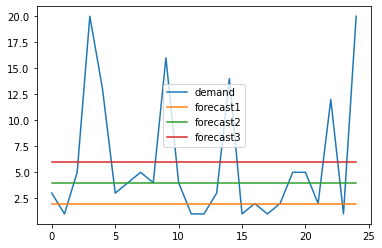

In [201]:
df.plot()
plt.show()

Calculate error metrics for each model!

Yes, we just copy/pasted some code, which works when you are trying to do something quickly, but can be prone to errors if you are copy/pasting a lot and updating values. Be careful.

In [202]:
# for forecast 1
print('bias:', np.mean(df['forecast1'] - df['demand']))
print('MAE:', mae(y_true=df['demand'], y_pred=df['forecast1']))
print('RMSE:', rmse(y_true=df['demand'], y_pred=df['forecast1']))

bias: -3.92
MAE: 4.4
RMSE: 7.116178749862878


In [203]:
# for forecast 2 (median)
print('bias:', np.mean(df['forecast2'] - df['demand']))
print('MAE:', mae(y_true=df['demand'], y_pred=df['forecast2']))
print('RMSE:', rmse(y_true=df['demand'], y_pred=df['forecast2']))

bias: -1.92
MAE: 4.08
RMSE: 6.241794613730894


In [204]:
# for forecast 3 (mean)
print('bias:', np.mean(df['forecast3'] - df['demand']))
print('MAE:', mae(y_true=df['demand'], y_pred=df['forecast3']))
print('RMSE:', rmse(y_true=df['demand'], y_pred=df['forecast3']))

bias: 0.08
MAE: 4.8
RMSE: 5.939696961966999


## What do we see?
Model2 has a better MAE while Model3 has a better bias and RMSE. Which model is better? Depends on the use case.

See p. 22 of textbook for more mathematical motivation/ a nice discussion on aggregating data over different time horizons when demand is intermittent.

##### **On Your Own:** try fitting a moving average model on these dataset and compare to baseline models.

Which 'window size' yields the most accurate model for this problem? Any concerns with overfitting?

# Conclusion

In the real-world, data is never neatly organized! You hope it is - in fact, it might even be your job to organize the data, but useful info may need to get reshaped into a useful format.

While we did a lot of typing of values manually here, we will strive not to do this too much in our class - it is better to read data from an external file (like a .csv) and manipulate it.

Later on, you will experiment with combining what you learned about moving averages with error metrics.